# CocoChorales note-detection parameter sweep

This notebook benchmarks note segmentation on the **materialized smoothed-pYIN pitch tracks**, using each stem's MIDI as the note reference. It never re-runs pitch detection and never injects symbolic mistakes.

The experiment is deliberately split in two:

1. Compare PELT and KernelCPD cost models with `jump=1` for every candidate, removing the old `h=5` versus `h=1` confound.
2. Hold the selected method fixed while sweeping pitch threshold, silence-gap confirmation, minimum-note factor, penalty scale, voicing threshold, transition exclusion, and adjacent-segment merging.

The implementation lives in `benchmarks/modules/note/NoteDetectionParamSweep.py`; the subprocess launcher is `benchmarks/scripts/note_detection_param_sweep.py`. Work is parallelized by stem and checkpointed per stem under `benchmarks/results/note/note_detection_param_sweep/checkpoints`. Tuning and holdout roles are assigned by whole chorale track, so stems from one chorale cannot leak across roles.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / 'app.py').is_file() and (path / 'benchmarks').is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from benchmarks.modules.note.NoteDetectionParamSweep import (
    METHOD_CONFIGS, ParameterAxes, load_results, parameter_grid,
)

OUTPUT_DIR = REPO_ROOT / 'benchmarks' / 'results' / 'note' / 'note_detection_param_sweep'
RUNNER = REPO_ROOT / 'benchmarks' / 'scripts' / 'note_detection_param_sweep.py'
WORKERS = max(1, (os.cpu_count() or 4) - 1)
FORCE_RECOMPUTE = False
SEED = 0
PER_STRATUM = 10
TUNE_PER_STRATUM = 8
MAX_STRATA = None       # set to 1 for a smoke run
MAX_TRACKS = None       # set to 1 for the smallest smoke run

print('repo:', REPO_ROOT)
print('workers:', WORKERS)
print('results:', OUTPUT_DIR)
print('method candidates:', ', '.join(METHOD_CONFIGS))

repo: /Users/sarah/Desktop/shasha/Attune
workers: 9
results: /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep
method candidates: pelt-l1, pelt-l2, pelt-rbf, kernelcpd-linear, kernelcpd-gaussian, kernelcpd-cosine


## 1. Fair PELT / KernelCPD comparison

Every candidate below receives `jump=1`, the same cached pitch frames, the same score-derived minimum segment length, the same production penalty rule, and the same transition post-processing. Selection uses stratum-balanced mean note F1 on tuning tracks; overlap and speed break ties. Holdout rows are reported but do not select the method.

In [2]:
method_command = [
    sys.executable, str(RUNNER),
    '--stage', 'methods',
    '--workers', str(WORKERS),
    '--output-dir', str(OUTPUT_DIR),
    '--seed', str(SEED),
    '--per-stratum', str(PER_STRATUM),
    '--tune-per-stratum', str(TUNE_PER_STRATUM),
]
if MAX_STRATA is not None:
    method_command += ['--max-strata', str(MAX_STRATA)]
if MAX_TRACKS is not None:
    method_command += ['--max-tracks', str(MAX_TRACKS)]
if FORCE_RECOMPUTE:
    method_command.append('--force')
print(' '.join(method_command))
subprocess.run(method_command, cwd=REPO_ROOT, check=True)

/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python /Users/sarah/Desktop/shasha/Attune/benchmarks/scripts/note_detection_param_sweep.py --stage methods --workers 9 --output-dir /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep --seed 0 --per-stratum 10 --tune-per-stratum 8


method tracks:   0%|          | 0/240 [00:00<?, ?it/s]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp_0uweeiv/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpc153bh2f/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpx5mlkih7/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpuconyghs/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpjn1v6ku7/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpmb13raa0/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpmxinjarf/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp8n42kr2e/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpjhnk6rcx/3_trombone.mid
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI 

method tracks:   0%|          | 1/240 [00:34<2:19:06, 34.92s/it]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpy30a70jb/3_trombone.mid
Handling MIDI file...


...

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpe_wr0dk4/1_flute.mid
Handling MIDI file...


method tracks:  96%|█████████▌| 230/240 [1:42:03<11:26, 68.67s/it]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpuciahfw4/2_oboe.mid
Handling MIDI file...
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp9frw1l4g/2_oboe.mid
Handling MIDI file...


method tracks: 100%|█████████▉| 239/240 [5:41:06<01:25, 85.64s/it]  
Process SpawnProcess-2:
Process SpawnProcess-7:
Process SpawnProcess-6:
Process SpawnProcess-8:
Process SpawnProcess-4:
Process SpawnProcess-1:
Process SpawnProcess-3:
Process SpawnProcess-5:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/anaconda3/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/anaconda3/lib/python3.12/concurrent/futures/process.py", line 251, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/lib/python3.12/multiprocessing/queues.py", line 102, in get
    with self._rlock:
  File "/opt/homebrew/anaconda3/lib/python3.12/multiprocessing/synchroni

KeyboardInterrupt: 

In [3]:
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from IPython.display import display

from benchmarks.modules.note.NoteDetectionParamSweep import (
    METHOD_CONFIGS,
    RUNNER_VERSION,
    choose_method,
    summarize,
)

# Uses the OUTPUT_DIR defined by the notebook setup cell.
out = Path(OUTPUT_DIR)
sample_path = out / "sample.csv"
checkpoint_root = out / "checkpoints"

sample = pd.read_csv(sample_path)

# Select the method checkpoint set containing the most completed stems.
checkpoint_dirs = list(checkpoint_root.glob("method-*"))
if not checkpoint_dirs:
    raise RuntimeError(f"No method checkpoints found under {checkpoint_root}")

checkpoint_dir = max(
    checkpoint_dirs,
    key=lambda path: (
        len(list(path.glob("*.json"))),
        path.stat().st_mtime,
    ),
)

# Checkpoint writes are atomic, so *.json excludes unfinished temporary files.
checkpoint_files = sorted(checkpoint_dir.glob("*.json"))
raw_rows = []

for path in checkpoint_files:
    payload = json.loads(path.read_text())
    if not isinstance(payload, list):
        raise ValueError(f"Unexpected checkpoint payload in {path}")
    raw_rows.extend(payload)

rows = pd.DataFrame(raw_rows)

required_columns = {
    "track_id",
    "ensemble",
    "instrument",
    "role",
    "method",
    "ruptures_algorithm",
    "model",
    "jump",
    "F-measure",
    "Precision",
    "Recall",
    "Average Overlap Ratio",
    "note_compute_time",
    "error",
}
missing_columns = required_columns - set(rows.columns)
if missing_columns:
    raise RuntimeError(f"Checkpoint rows are missing columns: {sorted(missing_columns)}")

# Ensure every saved stem contains one result for every method.
expected_methods = set(METHOD_CONFIGS)
method_sets = rows.groupby("track_id")["method"].apply(set)
incomplete_tracks = {
    track_id: sorted(expected_methods - methods)
    for track_id, methods in method_sets.items()
    if methods != expected_methods
}
if incomplete_tracks:
    raise RuntimeError(f"Incomplete checkpoint files: {incomplete_tracks}")

duplicates = rows.duplicated(["track_id", "method"])
if duplicates.any():
    duplicate_rows = rows.loc[duplicates, ["track_id", "method"]]
    raise RuntimeError(f"Duplicate checkpoint rows:\n{duplicate_rows}")

completed_track_ids = set(rows["track_id"])
missing = sample.loc[
    ~sample["track_id"].isin(completed_track_ids),
    ["track_id", "ensemble", "instrument", "role"],
].copy()

error_count = int(rows["error"].notna().sum())

print(f"Checkpoint set: {checkpoint_dir.name}")
print(f"Completed stems: {len(completed_track_ids)}/{len(sample)}")
print(f"Recovered result rows: {len(rows)}")
print(f"Rows with errors: {error_count}")

if not missing.empty:
    print("\nMissing stems:")
    display(missing)

missing_tune = missing.loc[missing["role"] == "tune"]
if not missing_tune.empty:
    raise RuntimeError(
        "At least one tuning stem is missing. Refusing to finalize method "
        "selection because it would be based on incomplete tuning data."
    )

# Produce the same stratum-balanced summary as a normally completed run.
summary = summarize(
    rows,
    ["method", "ruptures_algorithm", "model", "jump"],
)
selected_method = choose_method(summary)

def atomic_csv(frame: pd.DataFrame, path: Path) -> None:
    temporary = path.with_name(f".{path.name}.recovery.tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

def atomic_json(payload, path: Path) -> None:
    temporary = path.with_name(f".{path.name}.recovery.tmp")
    temporary.write_text(json.dumps(payload, indent=2, allow_nan=False))
    temporary.replace(path)

# Standard outputs consumed by load_results().
atomic_csv(rows, out / "method_rows.csv")
atomic_csv(summary, out / "method_summary.csv")

# Additional consolidated JSON copies.
atomic_json(
    json.loads(rows.to_json(orient="records")),
    out / "method_rows.json",
)
atomic_json(
    json.loads(summary.to_json(orient="records")),
    out / "method_summary.json",
)

selection_payload = {
    "method": selected_method,
    "selection_role": "tune",
    "selection_metric": "F-measure",
    "all_candidate_hops": 1,
    "recovered_from_checkpoints": True,
    "partial_holdout": not missing.empty,
    "completed_tracks": len(completed_track_ids),
    "total_tracks": len(sample),
    "missing_tracks": missing["track_id"].tolist(),
}
atomic_json(selection_payload, out / "selected_method.json")

metadata_payload = {
    "signature": checkpoint_dir.name.removeprefix("method-"),
    "runner_version": RUNNER_VERSION,
    "recovered_at_utc": datetime.now(timezone.utc).isoformat(),
    "recovered_from_checkpoints": True,
    "tracks": len(sample),
    "completed_tracks": len(completed_track_ids),
    "result_rows": len(rows),
    "variants": len(expected_methods),
    "errors": error_count,
    "missing_tracks": missing.to_dict(orient="records"),
}
atomic_json(metadata_payload, out / "method_metadata.json")

print(f"\nSelected method: {selected_method}")
print("Saved:")
for name in (
    "method_rows.csv",
    "method_rows.json",
    "method_summary.csv",
    "method_summary.json",
    "selected_method.json",
    "method_metadata.json",
):
    print(" ", out / name)

display(
    summary[
        [
            "role",
            "method",
            "Tracks",
            "Errors",
            "F-measure",
            "Precision",
            "Recall",
            "Average Overlap Ratio",
            "note_compute_time",
            "realtime_factor",
        ]
    ]
)

Checkpoint set: method-24c0da075e51bdd9
Completed stems: 239/240
Recovered result rows: 1434
Rows with errors: 0

Missing stems:


,track_id,ensemble,instrument,role
205,test__random_track235150__2_clarinet,random,clarinet,holdout



Selected method: kernelcpd-linear
Saved:
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/method_rows.csv
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/method_rows.json
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/method_summary.csv
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/method_summary.json
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/selected_method.json
  /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep/method_metadata.json


,role,method,Tracks,Errors,F-measure,Precision,Recall,Average Overlap Ratio,note_compute_time,realtime_factor
0,holdout,kernelcpd-linear,47,0,0.952517,0.949626,0.956223,0.920809,0.072064,335.798738
1,holdout,pelt-l2,47,0,0.952517,0.949626,0.956223,0.920809,17.652233,2.981843
2,holdout,pelt-l1,47,0,0.952237,0.949106,0.956223,0.920017,22.417694,2.291415
3,holdout,kernelcpd-gaussian,47,0,0.946687,0.943415,0.950790,0.919030,0.145856,185.498088
4,holdout,pelt-rbf,47,0,0.946687,0.943415,0.950790,0.919030,347.508940,2.101109
5,holdout,kernelcpd-cosine,47,0,0.832478,0.870516,0.800466,0.908175,0.079446,310.445372
6,tune,kernelcpd-linear,192,0,0.945427,0.941492,0.950462,0.918029,0.071630,330.919527
7,tune,pelt-l2,192,0,0.945427,0.941492,0.950462,0.918029,16.135274,3.206523
8,tune,pelt-l1,192,0,0.945351,0.941502,0.950298,0.917950,20.483465,2.504544
9,tune,kernelcpd-gaussian,192,0,0.942695,0.938532,0.947981,0.916406,0.138709,187.761427


,role,method,ruptures_algorithm,model,jump,Tracks,Errors,F-measure,Precision,Recall,Average Overlap Ratio,note_count_ratio,realtime_factor
0,holdout,kernelcpd-linear,kernelcpd,l2,1,47,0,0.952517,0.949626,0.956223,0.920809,1.004292,335.798738
1,holdout,pelt-l2,pelt,l2,1,47,0,0.952517,0.949626,0.956223,0.920809,1.004292,2.981843
2,holdout,pelt-l1,pelt,l1,1,47,0,0.952237,0.949106,0.956223,0.920017,1.005150,2.291415
3,holdout,kernelcpd-gaussian,kernelcpd,rbf,1,47,0,0.946687,0.943415,0.950790,0.919030,1.005150,185.498088
4,holdout,pelt-rbf,pelt,rbf,1,47,0,0.946687,0.943415,0.950790,0.919030,1.005150,2.101109
5,holdout,kernelcpd-cosine,kernelcpd,cosine,1,47,0,0.832478,0.870516,0.800466,0.908175,0.910730,310.445372
6,tune,kernelcpd-linear,kernelcpd,l2,1,192,0,0.945427,0.941492,0.950462,0.918029,1.009263,330.919527
7,tune,pelt-l2,pelt,l2,1,192,0,0.945427,0.941492,0.950462,0.918029,1.009263,3.206523
8,tune,pelt-l1,pelt,l1,1,192,0,0.945351,0.941502,0.950298,0.917950,1.009043,2.504544
9,tune,kernelcpd-gaussian,kernelcpd,rbf,1,192,0,0.942695,0.938532,0.947981,0.916406,1.010587,187.761427


Automatically selected from tuning rows: kernelcpd-linear


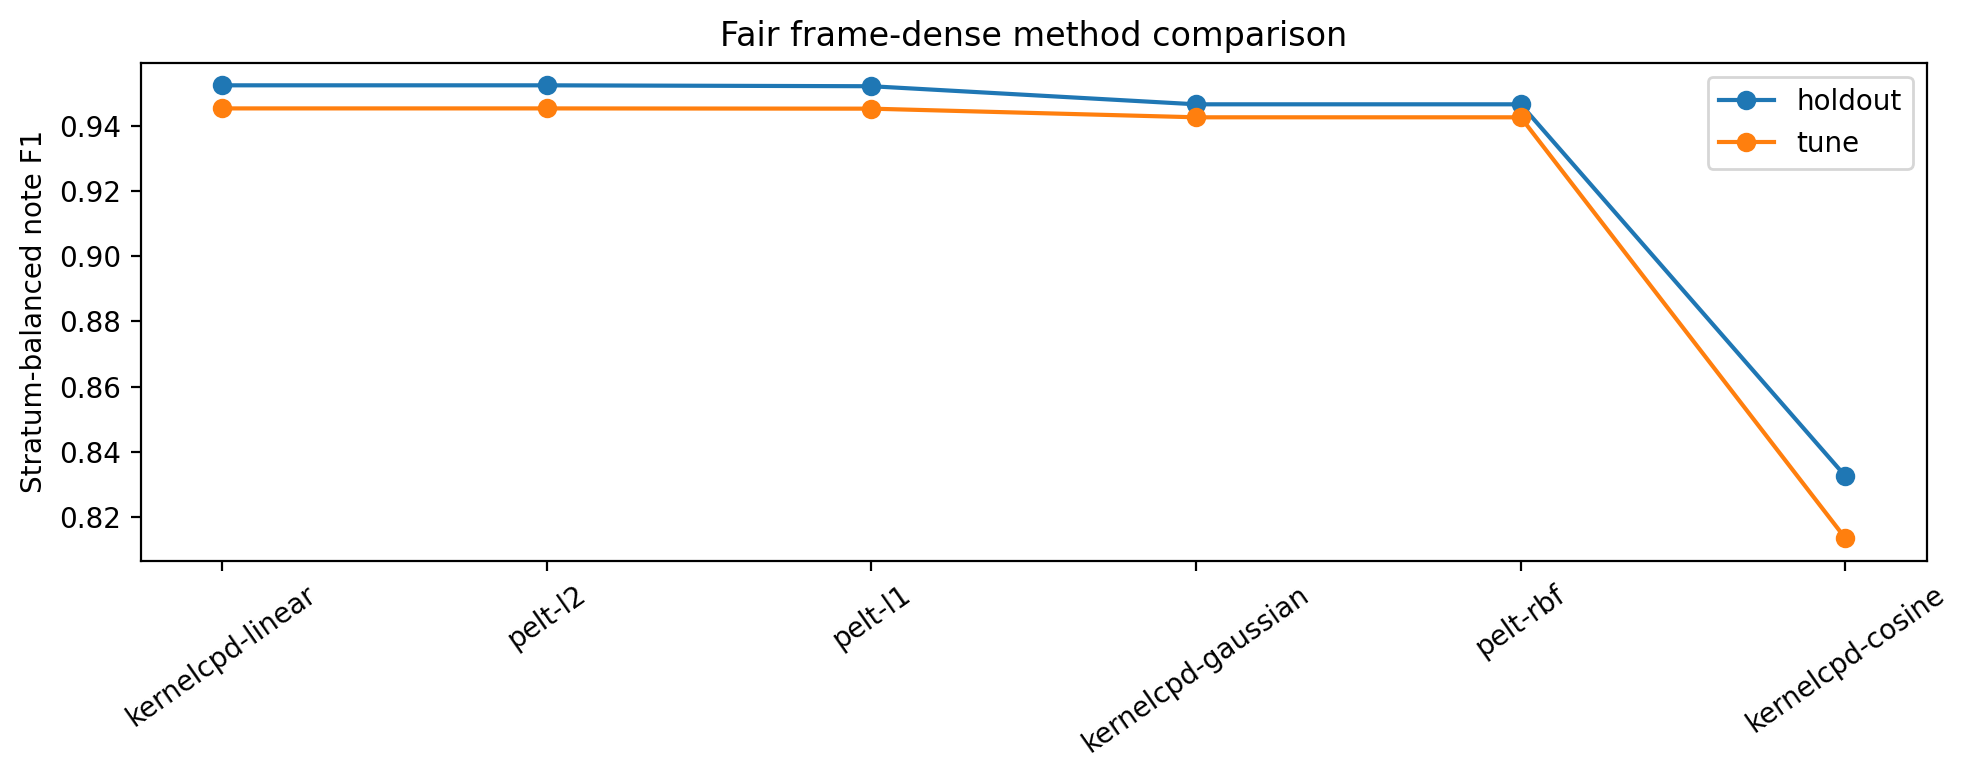

In [4]:
results = load_results(OUTPUT_DIR)
method_summary = results['method_summary']
selected_method = results['selected_method']['method']
METHOD_COLUMNS = [
    'role', 'method', 'ruptures_algorithm', 'model', 'jump', 'Tracks', 'Errors',
    'F-measure', 'Precision', 'Recall', 'Average Overlap Ratio',
    'note_count_ratio', 'realtime_factor',
]
display(method_summary[METHOD_COLUMNS])
assert method_summary['jump'].eq(1).all(), 'A method was not run at hop/jump=1'
print('Automatically selected from tuning rows:', selected_method)

fig, ax = plt.subplots(figsize=(10, 4))
for role, frame in method_summary.groupby('role'):
    ax.plot(frame['method'], frame['F-measure'], marker='o', label=role)
ax.set(ylabel='Stratum-balanced note F1', xlabel='', title='Fair frame-dense method comparison')
ax.tick_params(axis='x', rotation=35)
ax.legend()
fig.tight_layout()

## 2. Hold the method constant and sweep note-detection parameters

`FIXED_METHOD=None` uses the tuning winner from stage 1. Set it to a method label if you want to override that choice after inspecting the table.

`GRID_MODE='targeted'` is the practical default: it sweeps the interacting pitch/gap/penalty axes together, then the run-construction axes together, for 66 unique configurations. `GRID_MODE='full'` evaluates the complete 1,728-combination Cartesian product. All variants still force boundary hop 1. `gap_window_frames` is the odd-sized majority-unvoiced window used to confirm silence gaps; `1` splits on every unvoiced frame, while larger values require broader evidence.

In [10]:
import json
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "app.py").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate the Attune repository")
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / "benchmarks/results/note/note_detection_param_sweep"
WORKERS = globals().get("WORKERS", min(8, max(1, (os.cpu_count() or 4) - 1)))

cmd = [
    sys.executable,
    str(ROOT / "benchmarks/scripts/note_detection_param_sweep.py"),
    "--stage", "parameters",
    "--workers", str(WORKERS),
    "--output-dir", str(OUTPUT_DIR),
    "--fixed-method", "kernelcpd-linear",
    "--pitch-step-semitones", "0.25,0.5,0.75,1.0",
    "--min-note-length-factor", "0.5,0.75,1.0",
    "--min-silence-duration-ms", "3,10,20,40",
]

subprocess.run(cmd, cwd=ROOT, check=True)

parameter_summary = pd.read_csv(OUTPUT_DIR / "parameter_summary.csv")
recommendation = json.loads((OUTPUT_DIR / "recommendation.json").read_text())

display(parameter_summary)
print(json.dumps(recommendation, indent=2))

parameter tracks: 100%|██████████| 240/240 [00:43<00:00,  5.46it/s]


recommended parameters: {
  "method": "kernelcpd-linear",
  "pitch_step_semitones": 1.0,
  "min_note_length_factor": 0.5,
  "min_silence_duration_ms": 40.0
}


,role,method,pitch_step_semitones,min_note_length_factor,min_silence_duration_ms,Precision,Recall,F-measure,Average Overlap Ratio,Estimated Notes,Reference Notes,note_compute_time,realtime_factor,Tracks,Errors,note_count_ratio
0,holdout,kernelcpd-linear,0.50,1.00,3.0,0.965480,0.960231,0.961514,0.955388,23.854167,24.083333,0.030660,1078.209786,48,0,0.990484
1,holdout,kernelcpd-linear,0.75,1.00,3.0,0.967375,0.958337,0.961500,0.955280,23.750000,24.083333,0.032842,1011.008898,48,0,0.986159
2,holdout,kernelcpd-linear,0.50,1.00,10.0,0.963696,0.960231,0.960505,0.955384,23.895833,24.083333,0.030913,1065.629007,48,0,0.992215
3,holdout,kernelcpd-linear,0.75,1.00,10.0,0.965592,0.958337,0.960492,0.955275,23.791667,24.083333,0.032140,993.320288,48,0,0.987889
4,holdout,kernelcpd-linear,0.50,1.00,20.0,0.956250,0.958495,0.956664,0.955401,24.020833,24.083333,0.030345,1048.217237,48,0,0.997405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,tune,kernelcpd-linear,0.25,0.75,3.0,0.873344,0.943980,0.904386,0.904550,26.067708,23.614583,0.023985,1161.942280,192,0,1.103882
92,tune,kernelcpd-linear,0.25,0.50,40.0,0.779972,0.947000,0.848870,0.832726,29.973958,23.614583,0.023481,1195.592357,192,0,1.269299
93,tune,kernelcpd-linear,0.25,0.50,20.0,0.780505,0.946168,0.848848,0.833597,29.911458,23.614583,0.023828,1172.678006,192,0,1.266652
94,tune,kernelcpd-linear,0.25,0.50,10.0,0.780488,0.946056,0.848720,0.833655,29.911458,23.614583,0.023413,1182.725215,192,0,1.266652


{
  "method": "kernelcpd-linear",
  "pitch_step_semitones": 1.0,
  "min_note_length_factor": 0.5,
  "min_silence_duration_ms": 40.0,
  "selection_role": "tune",
  "selection_metric": "F-measure",
  "grid_mode": "full_cartesian",
  "transitions": false,
  "merge_adjacent": false,
  "tie_breaker": "note_count_bias_then_proximity_to_production_defaults"
}


In [6]:
FIXED_METHOD = 'kernelcpd-linear'  # e.g. 'pelt-l2'; None uses stage-1 selection
GRID_MODE = 'targeted'
AXES = ParameterAxes(
    pitch_thresh=(0.25, 0.5, 0.75, 1.0),
    gap_window_frames=(1, 3, 5, 7),
    min_note_factor=(0.5, 0.75, 1.0),
    penalty_scale=(0.5, 1.0, 2.0),
    unv_thresh=(0.8, 0.9, 0.95),
    exclude_transitions=(True, False),
    merge_adjacent=(True, False),
)
grid = parameter_grid(AXES, mode=GRID_MODE)
print(f'{len(grid)} parameter configurations ({GRID_MODE})')
display(pd.DataFrame(grid).nunique().rename('values swept').to_frame().T)

66 parameter configurations (targeted)


,pitch_thresh,gap_window_frames,min_note_factor,penalty_scale,unv_thresh,exclude_transitions,merge_adjacent
values swept,4,4,3,3,3,2,2


In [7]:
def csv_arg(values):
    return ','.join(str(value).lower() if isinstance(value, bool) else str(value) for value in values)

parameter_command = [
    sys.executable, str(RUNNER),
    '--stage', 'parameters',
    '--workers', str(WORKERS),
    '--output-dir', str(OUTPUT_DIR),
    '--seed', str(SEED),
    '--per-stratum', str(PER_STRATUM),
    '--tune-per-stratum', str(TUNE_PER_STRATUM),
    '--grid-mode', GRID_MODE,
    '--pitch-thresh', csv_arg(AXES.pitch_thresh),
    '--gap-window-frames', csv_arg(AXES.gap_window_frames),
    '--min-note-factor', csv_arg(AXES.min_note_factor),
    '--penalty-scale', csv_arg(AXES.penalty_scale),
    '--unv-thresh', csv_arg(AXES.unv_thresh),
    '--exclude-transitions', csv_arg(AXES.exclude_transitions),
    '--merge-adjacent', csv_arg(AXES.merge_adjacent),
]
if FIXED_METHOD is not None:
    parameter_command += ['--fixed-method', FIXED_METHOD]
if MAX_STRATA is not None:
    parameter_command += ['--max-strata', str(MAX_STRATA)]
if MAX_TRACKS is not None:
    parameter_command += ['--max-tracks', str(MAX_TRACKS)]
if FORCE_RECOMPUTE:
    parameter_command.append('--force')
print(' '.join(parameter_command))
subprocess.run(parameter_command, cwd=REPO_ROOT, check=True)

/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python /Users/sarah/Desktop/shasha/Attune/benchmarks/scripts/note_detection_param_sweep.py --stage parameters --workers 9 --output-dir /Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep --seed 0 --per-stratum 10 --tune-per-stratum 8 --grid-mode targeted --pitch-thresh 0.25,0.5,0.75,1.0 --gap-window-frames 1,3,5,7 --min-note-factor 0.5,0.75,1.0 --penalty-scale 0.5,1.0,2.0 --unv-thresh 0.8,0.9,0.95 --exclude-transitions true,false --merge-adjacent true,false --fixed-method kernelcpd-linear


parameter tracks:   0%|          | 0/240 [00:00<?, ?it/s]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp5y3a_mms/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp_xb4unhz/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp9jruvgf5/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpgf8kh60t/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp27ic72f4/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpo5cpefki/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpb31uxebg/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpx8e8g3ao/2_horn.mid
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp9nhdsxmp/3_trombone.mid
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI file...
Handling MIDI 

parameter tracks:   0%|          | 1/240 [00:04<19:41,  4.94s/it]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmpupcn8kaq/3_trombone.mid
Handling MIDI file...
Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp6yqwhh3d/3_trombone.mid
Handling MIDI file...


...

parameter tracks:  96%|█████████▌| 230/240 [02:00<00:05,  1.93it/s]

Loading score file: /var/folders/_1/wpkj3xlj2sxd981vsh_0fhd80000gn/T/tmp6dh1ydar/2_oboe.mid
Handling MIDI file...


parameter tracks: 100%|██████████| 240/240 [02:13<00:00,  1.80it/s]


recommended parameters: {
  "pitch_thresh": 0.5,
  "gap_window_frames": 3,
  "min_note_factor": 0.75,
  "penalty_scale": 1.0,
  "unv_thresh": 0.95,
  "exclude_transitions": false,
  "merge_adjacent": true,
  "method": "kernelcpd-linear"
}


CompletedProcess(args=['/Users/sarah/Desktop/shasha/Attune/at-venv/bin/python', '/Users/sarah/Desktop/shasha/Attune/benchmarks/scripts/note_detection_param_sweep.py', '--stage', 'parameters', '--workers', '9', '--output-dir', '/Users/sarah/Desktop/shasha/Attune/benchmarks/results/note/note_detection_param_sweep', '--seed', '0', '--per-stratum', '10', '--tune-per-stratum', '8', '--grid-mode', 'targeted', '--pitch-thresh', '0.25,0.5,0.75,1.0', '--gap-window-frames', '1,3,5,7', '--min-note-factor', '0.5,0.75,1.0', '--penalty-scale', '0.5,1.0,2.0', '--unv-thresh', '0.8,0.9,0.95', '--exclude-transitions', 'true,false', '--merge-adjacent', 'true,false', '--fixed-method', 'kernelcpd-linear'], returncode=0)

In [8]:
results = load_results(OUTPUT_DIR)
parameter_summary = results['parameter_summary']
recommendation = results['recommendation']
PARAM_COLUMNS = [
    'method', 'pitch_thresh', 'gap_window_frames', 'min_note_factor',
    'penalty_scale', 'unv_thresh', 'exclude_transitions', 'merge_adjacent',
]
RESULT_COLUMNS = [
    'role', *PARAM_COLUMNS, 'Tracks', 'Errors', 'F-measure', 'Precision', 'Recall',
    'Average Overlap Ratio', 'note_count_ratio', 'realtime_factor',
]
print('Recommended from tuning rows:')
print(json.dumps(recommendation, indent=2))
print('Top tuning configurations:')
display(parameter_summary.loc[parameter_summary.role == 'tune', RESULT_COLUMNS].head(20))
print('Same configuration on holdout:')
mask = parameter_summary['role'].eq('holdout')
for name in PARAM_COLUMNS:
    mask &= parameter_summary[name].eq(recommendation[name])
display(parameter_summary.loc[mask, RESULT_COLUMNS])

Recommended from tuning rows:
{
  "pitch_thresh": 0.5,
  "gap_window_frames": 3,
  "min_note_factor": 0.75,
  "penalty_scale": 1.0,
  "unv_thresh": 0.95,
  "exclude_transitions": false,
  "merge_adjacent": true,
  "method": "kernelcpd-linear",
  "selection_role": "tune",
  "selection_metric": "F-measure",
  "grid_mode": "targeted"
}
Top tuning configurations:


,role,method,pitch_thresh,gap_window_frames,min_note_factor,penalty_scale,unv_thresh,exclude_transitions,merge_adjacent,Tracks,Errors,F-measure,Precision,Recall,Average Overlap Ratio,note_count_ratio,realtime_factor
66,tune,kernelcpd-linear,0.5,3,0.75,1.0,0.95,False,True,192,0,0.946335,0.940515,0.953704,0.951980,1.016321,704.458207
67,tune,kernelcpd-linear,0.5,3,0.75,1.0,0.90,False,True,192,0,0.946335,0.940515,0.953704,0.951980,1.016321,704.217841
68,tune,kernelcpd-linear,0.5,3,0.75,1.0,0.80,False,True,192,0,0.946335,0.940515,0.953704,0.951980,1.016321,687.291715
69,tune,kernelcpd-linear,0.5,3,0.50,1.0,0.80,False,True,192,0,0.946133,0.937280,0.957158,0.946639,1.027790,711.260803
70,tune,kernelcpd-linear,0.5,3,0.50,1.0,0.95,False,True,192,0,0.946133,0.937280,0.957158,0.946639,1.027790,706.857425
71,tune,kernelcpd-linear,0.5,3,0.50,1.0,0.90,False,True,192,0,0.946133,0.937280,0.957158,0.946639,1.027790,696.094664
72,tune,kernelcpd-linear,0.5,7,0.75,0.5,0.90,True,True,192,0,0.945898,0.942329,0.950462,0.918368,1.008161,336.140475
73,tune,kernelcpd-linear,0.5,7,0.75,1.0,0.90,True,True,192,0,0.945898,0.942329,0.950462,0.918275,1.008161,328.861267
74,tune,kernelcpd-linear,0.5,7,0.75,2.0,0.90,True,True,192,0,0.945701,0.942605,0.949768,0.918706,1.006837,334.802649
75,tune,kernelcpd-linear,0.5,5,0.75,0.5,0.90,True,True,192,0,0.945651,0.941846,0.950462,0.918199,1.008602,329.150192


Same configuration on holdout:


,role,method,pitch_thresh,gap_window_frames,min_note_factor,penalty_scale,unv_thresh,exclude_transitions,merge_adjacent,Tracks,Errors,F-measure,Precision,Recall,Average Overlap Ratio,note_count_ratio,realtime_factor
5,holdout,kernelcpd-linear,0.5,3,0.75,1.0,0.95,False,True,48,0,0.954879,0.950782,0.959752,0.955986,1.007785,703.727826


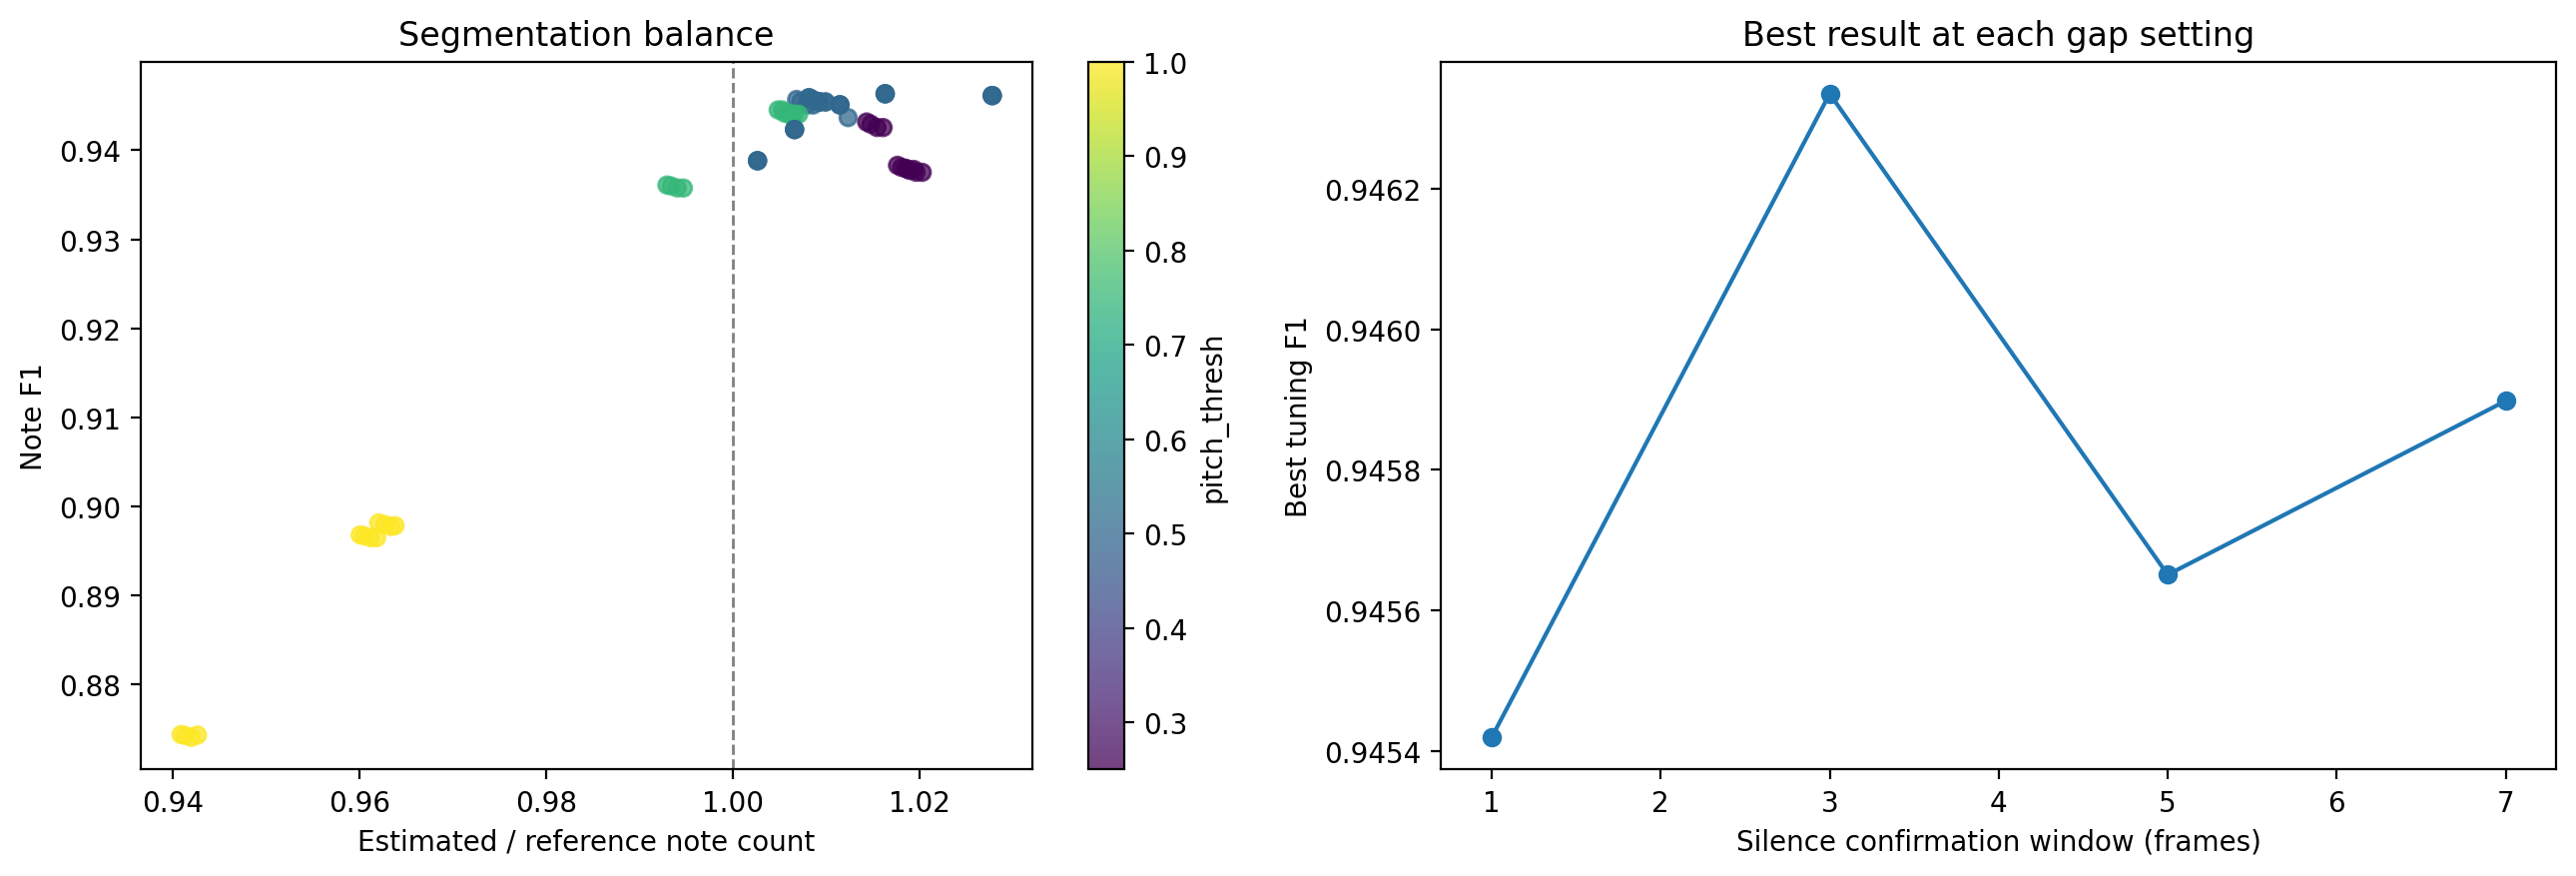

In [9]:
tune = parameter_summary.loc[parameter_summary.role == 'tune'].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
points = axes[0].scatter(
    tune['note_count_ratio'], tune['F-measure'],
    c=tune['pitch_thresh'], cmap='viridis', alpha=0.75,
)
axes[0].axvline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set(xlabel='Estimated / reference note count', ylabel='Note F1', title='Segmentation balance')
fig.colorbar(points, ax=axes[0], label='pitch_thresh')
gap_view = tune.groupby('gap_window_frames', as_index=False)['F-measure'].max()
axes[1].plot(gap_view['gap_window_frames'], gap_view['F-measure'], marker='o')
axes[1].set(xlabel='Silence confirmation window (frames)', ylabel='Best tuning F1', title='Best result at each gap setting')
fig.tight_layout()

## Reading the outputs

- `method_rows.csv` and `parameter_rows.csv` contain per-stem results.
- The summary CSVs first average within `(ensemble, instrument)` and then across strata, preventing a large instrument group from dominating.
- `F-measure` uses `mir_eval.transcription` with a 50 ms onset tolerance, pitch-aware note matching, constant detector-latency correction, and the same first/last-boundary treatment as the existing note benchmark.
- `note_count_ratio` makes over- and under-segmentation visible even when two configurations have similar F1.
- Stage checkpoints are signature-scoped. Changing tracks, axes, method, or runner version creates a new checkpoint set; `FORCE_RECOMPUTE=True` ignores matching checkpoints.